<a href="https://colab.research.google.com/github/faisalkhan6ai-sketch/AI-ML-Internship-Tasks/blob/main/Future_Stock_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_16231/1539810899.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Original Shape: (250, 5)
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982719  128.715417  122.097738  128.105769  112117500
2023-01-04  124.251183  126.512801  122.992546  124.772336   89113600
2023-01-05  122.933540  125.637646  122.677885  125.008327   80962700
2023-01-06  127.456795  128.115611  122.805737  123.907048   87754700
2023-01-09  127.977928  131.183532  127.722273  128.292595   70790800

Training rows: 200
Testing rows : 50

--- Random Forest Results ---
MAE  = $0.88
RMSE = $1.18


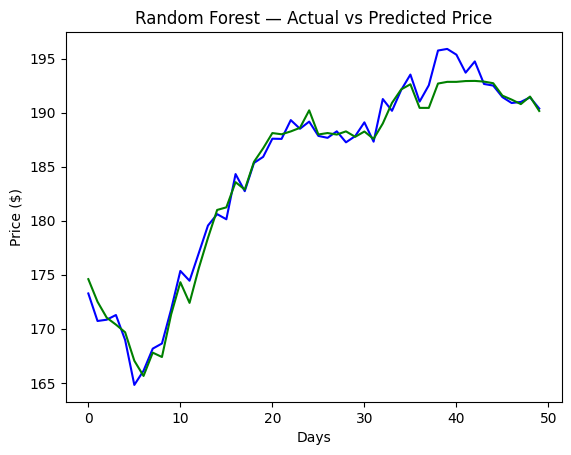

In [4]:
#Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


#Get Stock Data
df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
print("Original Shape:", df.shape)
print(df.head())


#Train/Test Split (Time Ordered!)
X = df[["Open", "High", "Low", "Volume"]]
y = df["Close"]

split = int(len(df) * 0.8)

X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

print("\nTraining rows:", len(X_train))
print("Testing rows :", len(X_test))


#Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)


#Evaluate Model (MAE & RMSE)
mae  = mean_absolute_error(y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("\n--- Random Forest Results ---")
print(f"MAE  = ${mae:.2f}")
print(f"RMSE = ${rmse:.2f}")


#Plot Actual vs Predicted
plt.plot(y_test.values,  label="Actual",    color="blue")
plt.plot(rf_predictions, label="Predicted", color="green")

plt.title("Random Forest — Actual vs Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.show()

